# Data Augmentation using CNN

## Project Overview
This project demonstrates how **Data Augmentation** improves the performance and generalization of Convolutional Neural Networks (CNNs). Data augmentation artificially increases the size and diversity of the training dataset by applying transformations such as rotation, flipping, zooming, and shifting.

## Objectives
- Understand the importance of data augmentation.
- Improve CNN model generalization.
- Reduce overfitting.
- Train and evaluate a CNN on augmented images.

## Technologies Used
- Python
- TensorFlow / Keras
- NumPy
- Matplotlib


In [ ]:
!pip install opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 7.0 MB/s eta 0:00:00


In [ ]:
!pip install tensorflow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 760.5 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 140.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 111.7 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


### Import Libraries
This cell imports the libraries required for image processing, model building, visualization, and data augmentation.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import cv2
import os
import PIL
import tensorflow as tf

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [ ]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = tf.keras.utils.get_file('flower_photos', origin=dataset_url,  cache_dir='.', untar=True)

228813984/228813984 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [ ]:
data_dir

'./datasets/flower_photos'

### Import Libraries
This cell imports the libraries required for image processing, model building, visualization, and data augmentation.

In [ ]:
import pathlib
data_dir = pathlib.Path(data_dir)
data_dir

PosixPath('datasets/flower_photos')

In [ ]:
list(data_dir.glob('*/*/*.jpg'))[:5]

[PosixPath('datasets/flower_photos/flower_photos/dandelion/13675534854_03caf51644_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/dandelion/570127230_ce409f90f8_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/dandelion/22190242684_8c3300d4e6.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/dandelion/4489359360_09db62f825.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/dandelion/4669006062_6b3d260037_n.jpg')]

In [ ]:
image_count = len(list(data_dir.glob('*/*/*.jpg')))
print(image_count)

3670


In [ ]:
roses = list(data_dir.glob('*/roses/*'))
roses[:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/7211616670_2d49ecb3a5_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/16339359979_6d742660b8_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/7419966772_d6c1c22a81.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/3102535578_ec8c12a7b6_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/4248222578_b4d5868b32.jpg')]

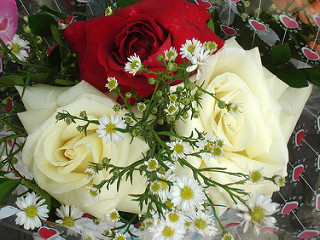

In [ ]:
PIL.Image.open(str(roses[1]))

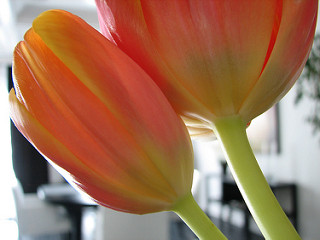

In [ ]:
tulips = list(data_dir.glob('*/tulips/*'))
PIL.Image.open(str(tulips[0]))

In [ ]:
flowers_images_dict = {
    'roses': list(data_dir.glob('*/roses/*')),
    'daisy': list(data_dir.glob('*/daisy/*')),
    'dandelion': list(data_dir.glob('*/dandelion/*')),
    'sunflowers': list(data_dir.glob('*/sunflowers/*')),
    'tulips': list(data_dir.glob('*/tulips/*')),
}

In [ ]:
flowers_labels_dict = {
    'roses': 0,
    'daisy': 1,
    'dandelion': 2,
    'sunflowers': 3,
    'tulips': 4,
}

In [ ]:
flowers_images_dict['roses'][:5]

[PosixPath('datasets/flower_photos/flower_photos/roses/7211616670_2d49ecb3a5_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/16339359979_6d742660b8_n.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/7419966772_d6c1c22a81.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/3102535578_ec8c12a7b6_m.jpg'),
 PosixPath('datasets/flower_photos/flower_photos/roses/4248222578_b4d5868b32.jpg')]

In [ ]:
str(flowers_images_dict['roses'][0])

'datasets/flower_photos/flower_photos/roses/7211616670_2d49ecb3a5_m.jpg'

In [ ]:
img = cv2.imread(str(flowers_images_dict['roses'][0]))

In [ ]:
img.shape

(240, 180, 3)

In [ ]:
cv2.resize(img,(180,180)).shape

(180, 180, 3)

In [ ]:
X, y = [], []

for flower_name, images in flowers_images_dict.items():
    for image in images:
        img = cv2.imread(str(image))
        resized_img = cv2.resize(img,(180,180))
        X.append(resized_img)
        y.append(flowers_labels_dict[flower_name])

In [ ]:
X = np.array(X)
y = np.array(y)

### Import Libraries
This cell imports the libraries required for image processing, model building, visualization, and data augmentation.

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

In [ ]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

### Train the CNN Model
The CNN is trained on the augmented dataset. During training, the model learns robust image features from different transformed samples.

In [ ]:
num_classes = 5

model = Sequential([
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.fit(X_train_scaled, y_train, epochs=5)

Epoch 1/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 30s 338ms/step - accuracy: 0.4117 - loss: 1.3325
Epoch 2/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 29s 338ms/step - accuracy: 0.5992 - loss: 1.0047
Epoch 3/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 29s 336ms/step - accuracy: 0.7013 - loss: 0.8199
Epoch 4/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 29s 335ms/step - accuracy: 0.7754 - loss: 0.5978
Epoch 5/5
86/86 ━━━━━━━━━━━━━━━━━━━━ 29s 337ms/step - accuracy: 0.8499 - loss: 0.4226


### Evaluate Model Performance
This section evaluates the trained CNN using the test dataset to measure its accuracy and loss.

In [ ]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 87ms/step - accuracy: 0.6089 - loss: 1.1585


[1.1584959030151367, 0.6089324355125427]

### Make Predictions
The trained model predicts the class labels for unseen images.

In [ ]:
predictions = model.predict(X_test_scaled)
predictions

29/29 ━━━━━━━━━━━━━━━━━━━━ 3s 88ms/step


array([[-1.7902927 ,  0.08931101,  0.4276497 , -1.7072603 , -0.4447983 ],
       [ 1.9317513 ,  0.33093637, -2.7612114 , -2.638851  ,  5.3225875 ],
       [-2.6232362 , -1.2327394 ,  1.9653916 , -1.0471803 , -1.8025103 ],
       ...,
       [-3.131836  , -3.2902067 , -0.53841776,  1.7467399 , -1.20536   ],
       [ 2.3367205 ,  1.3819165 ,  0.82222825, -4.3548574 , -0.31665725],
       [-2.0532026 , -2.3792846 , -1.7730169 ,  2.4208891 , -2.7255003 ]],
      dtype=float32)

### Import Libraries
This cell imports the libraries required for image processing, model building, visualization, and data augmentation.

In [ ]:
import tensorflow as tf
score = tf.nn.softmax(predictions[0])

In [ ]:
np.argmax(score)

np.int64(2)

In [ ]:
y_test[0]

np.int64(1)

### Import Libraries
This cell imports the libraries required for image processing, model building, visualization, and data augmentation.

In [ ]:
from tensorflow import keras
from tensorflow.keras import layers
img_height = 180
img_width = 180

data_augmentation = keras.Sequential([
    layers.Resizing(img_height, img_width),
    layers.RandomFlip("horizontal", input_shape=(img_height, img_width, 3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


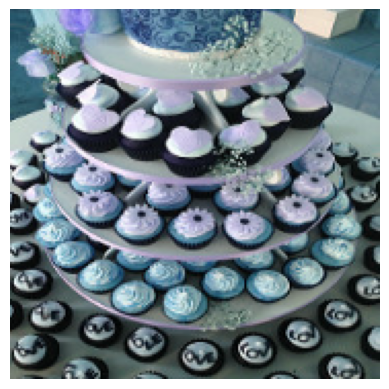

In [ ]:
plt.axis('off')
plt.imshow(X[0])

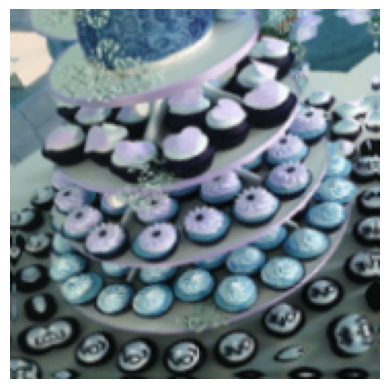

In [ ]:
plt.axis('off')
plt.imshow(data_augmentation(X)[0].numpy().astype("uint8"))
plt.show()

### Train the CNN Model
The CNN is trained on the augmented dataset. During training, the model learns robust image features from different transformed samples.

In [ ]:
num_classes = 5

model = Sequential([
  data_augmentation,
  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),
  layers.Dropout(0.2),
  layers.Flatten(),
  layers.Dense(128, activation='relu'),
  layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.fit(X_train_scaled, y_train, epochs=30)

Epoch 1/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 35s 392ms/step - accuracy: 0.3837 - loss: 1.4390
Epoch 2/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 34s 394ms/step - accuracy: 0.5698 - loss: 1.0765
Epoch 3/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 34s 390ms/step - accuracy: 0.6406 - loss: 0.9464
Epoch 4/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 34s 391ms/step - accuracy: 0.6602 - loss: 0.8821
Epoch 5/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 33s 389ms/step - accuracy: 0.6882 - loss: 0.8151
Epoch 6/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 33s 389ms/step - accuracy: 0.6930 - loss: 0.7972
Epoch 7/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 34s 390ms/step - accuracy: 0.7180 - loss: 0.7276
Epoch 8/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 34s 391ms/step - accuracy: 0.7358 - loss: 0.7006
Epoch 9/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 34s 391ms/step - accuracy: 0.7456 - loss: 0.6759
Epoch 10/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 34s 390ms/step - accuracy: 0.7471 - loss: 0.6610
Epoch 11/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 33s 388ms/step - accuracy: 0.7558 - loss: 0.6277
Epoch 12/30
86/86 ━━━━━━━━━━━━━━━━━━━━ 33

### Evaluate Model Performance
This section evaluates the trained CNN using the test dataset to measure its accuracy and loss.

In [ ]:
model.evaluate(X_test_scaled,y_test)

29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 83ms/step - accuracy: 0.6917 - loss: 1.0578


[1.05776846408844, 0.6917211413383484]

## Conclusion
Data augmentation is an effective technique for improving CNN performance, especially when limited training data is available. It increases dataset diversity, reduces overfitting, and helps build models that generalize better to unseen images.